# MSTL + Mixture of Experts Boosting

## Why MSTL over Fourier?
Fourier analysis assumes stationary cyclical behavior. Real-world power markets have non-stationary macro-trends (yearly seasonality, economic growth, weather drift) that Fourier cannot capture, leading to severe divergence on unseen test sets.

**MSTL (Multiple Seasonal-Trend decomposition using LOESS)** solves this by:
1. Extracting stable **Daily (96)** and **Weekly (672)** seasonal shapes via LOESS
2. Isolating the **Trend + Residuals** (containing macro-drift, holiday anomalies, weather variations)
3. Letting LightGBM predict the trend/residuals using external `demand_forecast` which embeds future macro-trends

## Architecture
1. **MSTL Baseline**: Extract daily+weekly seasonality, save last week as "seasonal template"
2. **Boost Target**: `Actual - Seasonal_Total` (contains trend + anomalies)
3. **Expert 1 — Workday**: LightGBM specialist for weekday trend prediction
4. **Expert 2 — Weekend/Holiday**: LightGBM specialist for non-working days
5. **Expert 3 — Spike**: LightGBM with upweighted top-10% errors for anomalies

### Prediction Formula
```
prediction = seasonal_template[dayofweek, hour, minute]
           + expert_workday_pred    (if workday)
           + expert_weekend_pred    (if weekend/holiday)
           + expert_spike_pred      (all rows)
```

In [0]:
%pip install lightgbm holidays "statsmodels>=0.14.0" ephem --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import holidays
import ephem
import math
import warnings
from statsmodels.tsa.seasonal import MSTL
from pyspark.sql import functions as F, Window
from pyspark.sql.types import StructType, StructField, TimestampType, DoubleType
from datetime import date, timedelta, datetime

warnings.filterwarnings("ignore")

In [0]:
# Load raw consumption
raw = spark.table("datathon.shared.client_consumption")

# Aggregate to portfolio 15-min totals (local time — avoids DST duplicates)
agg = (
    raw
    .withColumn("datetime_15min", F.window("datetime_local", "15 minutes").start)
    .groupBy("datetime_15min")
    .agg(
        F.sum("active_kw").alias("total_kw"),
        F.countDistinct("client_id").alias("n_clients"),
        F.first(F.window("datetime_utc", "15 minutes").start).alias("datetime_15min_utc"),
    )
    .orderBy("datetime_15min")
)
print(f"Portfolio rows: {agg.count():,}")

Portfolio rows: 32,056


In [0]:
# External Feature Joins
# 1. Shared demand/PV/wind forecasts
# 2. Population-weighted weather (temp, GHI, cloud_cover)
# 3. ERA5 HDD/CDD by community → portfolio-weighted

# Client weights by community for population-weighted weather
client_weights = (
    spark.table("datathon.shared.client_consumption")
    .groupBy("community_code")
    .agg(F.countDistinct("client_id").alias("n_clients"))
)
total_clients = client_weights.agg(F.sum("n_clients")).collect()[0][0]
client_weights = client_weights.withColumn("weight", F.col("n_clients") / F.lit(total_clients))
print(f"Total clients: {total_clients}")

# shared forecast tables
for tbl, alias in [
    ("datathon.shared.demand_forecast", "demand_forecast"),
    ("datathon.shared.pv_production_forecast", "pv_forecast"),
    ("datathon.shared.wind_production_forecast", "wind_forecast"),
]:
    try:
        fc = (
            spark.table(tbl)
            .withColumn("datetime_15min",
                F.from_unixtime(
                    F.unix_timestamp("datetime_utc") - (F.unix_timestamp("datetime_utc") % 900)
                ).cast("timestamp"))
            .groupBy("datetime_15min")
            .agg(F.avg("value").alias(alias))
        )
        if "features_spk" not in dir():
            features_spk = agg.join(fc, on="datetime_15min", how="left")
        else:
            features_spk = features_spk.join(fc, on="datetime_15min", how="left")
        print(f"✓ Joined {alias}")
    except Exception as e:
        if "features_spk" not in dir():
            features_spk = agg.withColumn(alias, F.lit(None).cast("double"))
        else:
            features_spk = features_spk.withColumn(alias, F.lit(None).cast("double"))
        print(f"✗ {alias}: {e}")

# Population-weighted weather (temp, GHI, cloud_cover)
try:
    weather_raw = (
        spark.table("datathon.underfitted_genius.wfp_weather_raw_hourly")
        .select(
            "datetime_utc", "location_id",
            F.col("temperature_2m").alias("temp_2m"),
            F.col("apparent_temperature").alias("apparent_temp"),
            F.col("shortwave_radiation").alias("ghi"),
            "cloud_cover",
            "precipitation",
        )
        .join(client_weights.select(
            F.col("community_code").alias("location_id"), "weight"
        ), on="location_id", how="inner")
    )
    
    # Compute population-weighted averages
    weather_agg = (
        weather_raw
        .withColumn("datetime_15min",
            F.from_unixtime(
                F.unix_timestamp("datetime_utc") - (F.unix_timestamp("datetime_utc") % 900)
            ).cast("timestamp"))
        .groupBy("datetime_15min")
        .agg(
            F.sum(F.col("temp_2m") * F.col("weight")).alias("wtd_temp"),
            F.sum(F.col("apparent_temp") * F.col("weight")).alias("wtd_apparent_temp"),
            F.sum(F.col("ghi") * F.col("weight")).alias("wtd_ghi"),
            F.sum(F.col("cloud_cover") * F.col("weight")).alias("wtd_cloud_cover"),
            F.sum(F.col("precipitation") * F.col("weight")).alias("wtd_precipitation"),
        )
    )
    features_spk = features_spk.join(weather_agg, on="datetime_15min", how="left")
    print("✓ Joined population-weighted weather (temp, GHI, cloud_cover, precipitation)")
except Exception as e:
    for c in ["wtd_temp", "wtd_apparent_temp", "wtd_ghi", "wtd_cloud_cover", "wtd_precipitation"]:
        features_spk = features_spk.withColumn(c, F.lit(None).cast("double"))
    print(f"✗ Weather: {e}")

# Population-weighted HDD / CDD from ERA5
try:
    era5 = (
        spark.table("datathon.underfitted_genius.temperature_era5_by_community")
        .join(client_weights, on="community_code", how="inner")
        .withColumn("datetime_15min",
            F.from_unixtime(
                F.unix_timestamp("datetime_utc") - (F.unix_timestamp("datetime_utc") % 900)
            ).cast("timestamp"))
        .groupBy("datetime_15min")
        .agg(
            F.sum(F.col("HDD") * F.col("weight")).alias("wtd_hdd"),
            F.sum(F.col("CDD") * F.col("weight")).alias("wtd_cdd"),
        )
    )
    features_spk = features_spk.join(era5, on="datetime_15min", how="left")
    print("✓ Joined population-weighted HDD/CDD")
except Exception as e:
    for c in ["wtd_hdd", "wtd_cdd"]:
        features_spk = features_spk.withColumn(c, F.lit(None).cast("double"))
    print(f"✗ HDD/CDD: {e}")

# Convert to Pandas + Calendar Features
pdf = features_spk.orderBy("datetime_15min").toPandas()
pdf["datetime_15min"] = pd.to_datetime(pdf["datetime_15min"])

# Spanish holidays (2024-2027)
es_holidays = holidays.ES(years=[2024, 2025, 2026, 2027])

# Calendar features
pdf["is_holiday"] = pdf["datetime_15min"].dt.date.apply(lambda x: x in es_holidays).astype(int)
pdf["dayofweek"] = pdf["datetime_15min"].dt.dayofweek
pdf["hour"] = pdf["datetime_15min"].dt.hour
pdf["minute"] = pdf["datetime_15min"].dt.minute
pdf["dayofyear"] = pdf["datetime_15min"].dt.dayofyear
pdf["month"] = pdf["datetime_15min"].dt.month
pdf["is_weekend"] = pdf["dayofweek"].isin([5, 6]).astype(int)
pdf["is_workday"] = ((pdf["is_weekend"] == 0) & (pdf["is_holiday"] == 0)).astype(int)

TARGET = "total_kw"

# Forward-fill all external/weather columns
fill_cols = [c for c in pdf.columns if c.startswith(("demand_", "pv_", "wind_", "wtd_"))]
for col in fill_cols:
    pdf[col] = pdf[col].ffill().fillna(0)

print(f"\nFeature matrix: {pdf.shape}")
print(f"Date range: {pdf['datetime_15min'].min()} → {pdf['datetime_15min'].max()}")
print(f"Weather columns: {[c for c in pdf.columns if c.startswith('wtd_')]}")

Total clients: 8393
✓ Joined demand_forecast
✓ Joined pv_forecast
✓ Joined wind_forecast
✓ Joined population-weighted weather (temp, GHI, cloud_cover, precipitation)
✓ Joined population-weighted HDD/CDD

Feature matrix: (32056, 22)
Date range: 2025-01-01 00:00:00 → 2025-11-30 23:45:00
Weather columns: ['wtd_temp', 'wtd_apparent_temp', 'wtd_ghi', 'wtd_cloud_cover', 'wtd_precipitation', 'wtd_hdd', 'wtd_cdd']


In [0]:
# Advanced Features: Solar, DST, Lags, Cultural Events, Temperature Gradients, Night Interactions

# Guard against duplicate columns from re-runs
pdf = pdf.loc[:, ~pdf.columns.duplicated()]

# Drop columns that will be recomputed
_recompute = ["sunrise_hour","sunset_hour","daylight_hours","mins_since_sunrise",
              "mins_until_sunset","is_twilight","days_since_dst","is_dst_week",
              "lag_48h","lag_7d","lag_14d","lag_7d_to_14d_diff","rolling_48h_mean",
              "rolling_7d_std","is_black_friday","is_black_week","is_pre_bridge_dec",
              "is_xmas_lights_evening","days_until_puente_dic","industrial_urgency",
              "daily_mean_temp","daily_min_temp","daily_max_temp",
              "temp_gradient_24h","temp_gradient_48h",
              "is_night","night_x_temp","night_x_hdd","night_x_cloud","night_x_daily_min"]
pdf = pdf.drop(columns=[c for c in _recompute if c in pdf.columns], errors="ignore")

# Solar Geometry(Madrid: 40.4168°N, 3.7038°W)
observer = ephem.Observer()
observer.lat, observer.lon = str(40.4168), str(-3.7038)
observer.elevation, observer.pressure = 650, 0

solar_dict = {}
for d in pdf["datetime_15min"].dt.date.unique():
    observer.date = ephem.Date(datetime(d.year, d.month, d.day, 12, 0, 0))
    try:
        sr = ephem.localtime(observer.previous_rising(ephem.Sun()))
        ss = ephem.localtime(observer.next_setting(ephem.Sun()))
        solar_dict[d] = {"sunrise_hour": sr.hour + sr.minute/60.0, "sunset_hour": ss.hour + ss.minute/60.0}
    except Exception:
        solar_dict[d] = {"sunrise_hour": 7.0, "sunset_hour": 18.0}

solar_df = pd.DataFrame.from_dict(solar_dict, orient="index").reset_index()
solar_df.columns = ["_date", "sunrise_hour", "sunset_hour"]
pdf["_date"] = pdf["datetime_15min"].dt.date
pdf = pdf.merge(solar_df, on="_date", how="left").drop(columns=["_date"])

hd = pdf["hour"] + pdf["minute"] / 60.0
pdf["daylight_hours"] = pdf["sunset_hour"] - pdf["sunrise_hour"]
pdf["mins_since_sunrise"] = ((hd - pdf["sunrise_hour"]) * 60).clip(lower=0)
pdf["mins_until_sunset"] = ((pdf["sunset_hour"] - hd) * 60).clip(lower=0)
pdf["is_twilight"] = (
    ((hd >= pdf["sunrise_hour"]-0.5) & (hd <= pdf["sunrise_hour"]+0.5)) |
    ((hd >= pdf["sunset_hour"]-0.5) & (hd <= pdf["sunset_hour"]+0.5))
).astype(int)
print(f"✓ Solar geometry")

# DST transitions
def last_sunday(year, month):
    import calendar
    ld = calendar.monthrange(year, month)[1]
    d = date(year, month, ld)
    while d.weekday() != 6: d -= timedelta(days=1)
    return d

dst_transitions = sorted([last_sunday(yr, m) for yr in [2024,2025,2026,2027] for m in [3,10]])

def days_since_dst(dt):
    d = dt.date() if hasattr(dt, 'date') else dt
    past = [t for t in dst_transitions if t <= d]
    return (d - past[-1]).days if past else 365

pdf["days_since_dst"] = pdf["datetime_15min"].apply(days_since_dst)
pdf["is_dst_week"] = (pdf["days_since_dst"] <= 7).astype(int)
print(f"✓ DST transitions")

# Safe lag features (no data leakage: lag_1d is data leakage because trades occur at 12:00 of the previous day)
pdf = pdf.sort_values("datetime_15min").reset_index(drop=True)
pdf["lag_48h"] = pdf[TARGET].shift(192)
pdf["lag_7d"] = pdf[TARGET].shift(672)
pdf["lag_14d"] = pdf[TARGET].shift(1344)
pdf["lag_7d_to_14d_diff"] = pdf["lag_7d"] - pdf["lag_14d"]
pdf["rolling_48h_mean"] = pdf[TARGET].shift(192).rolling(192, min_periods=96).mean()
pdf["rolling_7d_std"] = pdf[TARGET].shift(192).rolling(672, min_periods=192).std()
print(f"✓ Safe lags")

# Hardcoded cultural/economic events
# Pre-computed dates; no dynamic calculation needed.
HARDCODED_EVENTS = {
    2025: {"bf": date(2025,11,28), "bw": (date(2025,11,24), date(2025,11,30)), "puente": date(2025,12,6)},
    2026: {"bf": date(2026,11,27), "bw": (date(2026,11,23), date(2026,11,29)), "puente": date(2026,12,6)},
    2027: {"bf": date(2027,11,26), "bw": (date(2027,11,22), date(2027,11,28)), "puente": date(2027,12,6)},
}

pdf["_d"] = pdf["datetime_15min"].dt.date
pdf["_y"] = pdf["datetime_15min"].dt.year

pdf["is_black_friday"] = pdf.apply(
    lambda r: int(HARDCODED_EVENTS.get(r["_y"], {}).get("bf") == r["_d"]), axis=1)

pdf["is_black_week"] = pdf.apply(
    lambda r: int(HARDCODED_EVENTS.get(r["_y"], {}).get("bw", (None,None))[0] is not None and
              HARDCODED_EVENTS[r["_y"]]["bw"][0] <= r["_d"] <= HARDCODED_EVENTS[r["_y"]]["bw"][1])
    if r["_y"] in HARDCODED_EVENTS else 0, axis=1)

pdf["is_pre_bridge_dec"] = pdf.apply(
    lambda r: int(r["_d"].month == 11 and r["_d"].day >= 25), axis=1)

pdf["is_xmas_lights_evening"] = (
    (pdf["is_black_friday"] == 1) & (pdf["hour"] >= 19) & (pdf["hour"] < 22)
).astype(int)

def _days_until_puente(r):
    ev = HARDCODED_EVENTS.get(r["_y"])
    if ev is None: return 365
    d = (ev["puente"] - r["_d"]).days
    return max(d, 0) if d >= 0 else 365

pdf["days_until_puente_dic"] = pdf.apply(_days_until_puente, axis=1)
pdf["industrial_urgency"] = np.where(
    (pdf["days_until_puente_dic"] > 0) & (pdf["days_until_puente_dic"] <= 30),
    1.0 / pdf["days_until_puente_dic"], 0.0)

pdf = pdf.drop(columns=["_d", "_y"])
print(f"✓ Cultural events (hardcoded): BW={pdf['is_black_week'].sum()}, BF={pdf['is_black_friday'].sum()}, "
      f"PreBridge={pdf['is_pre_bridge_dec'].sum()}, XmasLights={pdf['is_xmas_lights_evening'].sum()}")

# Temp gradients (shock > absolute)
# Iberian market reacts to temperature shock more than absolute temp.
if "wtd_temp" in pdf.columns:
    daily_temp = pdf.groupby(pdf["datetime_15min"].dt.date)["wtd_temp"].agg(["mean","min","max"]).reset_index()
    daily_temp.columns = ["_date", "daily_mean_temp", "daily_min_temp", "daily_max_temp"]
    daily_temp["temp_gradient_24h"] = daily_temp["daily_max_temp"] - daily_temp["daily_max_temp"].shift(1)
    daily_temp["temp_gradient_48h"] = daily_temp["daily_max_temp"] - daily_temp["daily_max_temp"].shift(2)
    daily_temp = daily_temp.fillna(0)

    pdf["_date"] = pdf["datetime_15min"].dt.date
    pdf = pdf.merge(daily_temp, on="_date", how="left").drop(columns=["_date"])
    pdf[["temp_gradient_24h", "temp_gradient_48h", "daily_min_temp"]] = \
        pdf[["temp_gradient_24h", "temp_gradient_48h", "daily_min_temp"]].fillna(0)
    print(f"✓ Temp gradients: 24h range [{pdf['temp_gradient_24h'].min():.1f}, {pdf['temp_gradient_24h'].max():.1f}]")

# Night temp interaction
# Cold nights drive heating loads that raise the nighttime floor.
pdf["is_night"] = ((pdf["hour"] >= 22) | (pdf["hour"] < 6)).astype(int)
pdf["night_x_temp"] = pdf["is_night"] * pdf.get("wtd_temp", 0)
pdf["night_x_hdd"] = pdf["is_night"] * pdf.get("wtd_hdd", 0)
pdf["night_x_cloud"] = pdf["is_night"] * pdf.get("wtd_cloud_cover", 0)
if "daily_min_temp" in pdf.columns:
    pdf["night_x_daily_min"] = pdf["is_night"] * pdf["daily_min_temp"]
print(f"✓ Night interactions: is_night={pdf['is_night'].sum():,} intervals")

print(f"\nFinal feature matrix: {pdf.shape}")

✓ Solar geometry
✓ DST transitions
✓ Safe lags
✓ Cultural events (hardcoded): BW=672, BF=96, PreBridge=576, XmasLights=12
✓ Temp gradients: 24h range [-4.5, 4.4]
✓ Night interactions: is_night=10,680 intervals

Final feature matrix: (32056, 52)


In [0]:
# MSTL Decomposition + Feature Columns

TRAIN_END = "2025-10-01"
VAL_END   = "2025-11-01"
TEST_END  = "2025-12-01"

train_mask = pdf["datetime_15min"] < TRAIN_END
val_mask   = (pdf["datetime_15min"] >= TRAIN_END) & (pdf["datetime_15min"] < VAL_END)
test_mask  = (pdf["datetime_15min"] >= VAL_END) & (pdf["datetime_15min"] < TEST_END)
print(f"Train: {train_mask.sum():,}  Val: {val_mask.sum():,}  Test: {test_mask.sum():,}")

# MSTL decomposition
train_df = pdf.loc[train_mask].copy()
train_df[TARGET] = train_df[TARGET].interpolate(method="linear", limit_direction="both")
print(f"\nFitting MSTL (periods=96, 672)...")
mstl = MSTL(train_df[TARGET].values, periods=(96, 672), iterate=2)
mstl_res = mstl.fit()
train_df["season_96"] = mstl_res.seasonal[:, 0]
train_df["season_672"] = mstl_res.seasonal[:, 1]
train_df["season_total"] = train_df["season_96"] + train_df["season_672"]
print(f"MSTL done. Trend: [{mstl_res.trend.min():,.0f}, {mstl_res.trend.max():,.0f}]")

# Seasonal template
template_df = train_df.iloc[-672:][["dayofweek", "hour", "minute", "season_total"]].copy()
seasonal_template = template_df.groupby(["dayofweek", "hour", "minute"])["season_total"].mean().reset_index()
pdf = pdf.merge(seasonal_template, on=["dayofweek", "hour", "minute"], how="left")
pdf["season_total"] = pdf["season_total"].ffill().fillna(0)
pdf["boost_target"] = pdf[TARGET] - pdf["season_total"]

# Feature columns — all groups

def _cols_present(names):
    return [c for c in names if c in pdf.columns]

calendar_cols = ["dayofyear", "month", "dayofweek", "hour", "minute",
                 "is_holiday", "is_weekend", "is_workday"]
ext_cols = _cols_present([c for c in pdf.columns if c.startswith(("demand_","pv_","wind_"))])
weather_cols = _cols_present([c for c in pdf.columns if c.startswith("wtd_")])
solar_cols = _cols_present(["sunrise_hour", "sunset_hour", "daylight_hours",
              "mins_since_sunrise", "mins_until_sunset", "is_twilight"])
dst_cols = _cols_present(["days_since_dst", "is_dst_week"])
lag_cols = _cols_present(["lag_48h", "lag_7d", "lag_14d", "lag_7d_to_14d_diff",
                          "rolling_48h_mean", "rolling_7d_std"])
event_cols = _cols_present(["is_black_friday", "is_black_week", "is_pre_bridge_dec",
                            "is_xmas_lights_evening", "days_until_puente_dic",
                            "industrial_urgency"])
gradient_cols = _cols_present(["temp_gradient_24h", "temp_gradient_48h", "daily_min_temp"])
night_cols = _cols_present(["is_night", "night_x_temp", "night_x_hdd",
                            "night_x_cloud", "night_x_daily_min"])

FEATURE_COLS = list(dict.fromkeys(
    calendar_cols + ext_cols + weather_cols + solar_cols + dst_cols
    + lag_cols + event_cols + gradient_cols + night_cols
))

for c in lag_cols:
    pdf[c] = pdf[c].fillna(0)

print(f"\nLGB features ({len(FEATURE_COLS)}):")
for grp, cols in [("Calendar", calendar_cols), ("External", ext_cols),
                   ("Weather", weather_cols), ("Solar", solar_cols),
                   ("DST", dst_cols), ("Lags", lag_cols),
                   ("Events", event_cols), ("TempGrad", gradient_cols),
                   ("NightInt", night_cols)]:
    if cols: print(f"  {grp:10s}: {cols}")

Train: 26,200  Val: 2,976  Test: 2,880

Fitting MSTL (periods=96, 672)...
MSTL done. Trend: [130,976, 359,194]

LGB features (46):
  Calendar  : ['dayofyear', 'month', 'dayofweek', 'hour', 'minute', 'is_holiday', 'is_weekend', 'is_workday']
  External  : ['demand_forecast', 'pv_forecast', 'wind_forecast']
  Weather   : ['wtd_temp', 'wtd_apparent_temp', 'wtd_ghi', 'wtd_cloud_cover', 'wtd_precipitation', 'wtd_hdd', 'wtd_cdd']
  Solar     : ['sunrise_hour', 'sunset_hour', 'daylight_hours', 'mins_since_sunrise', 'mins_until_sunset', 'is_twilight']
  DST       : ['days_since_dst', 'is_dst_week']
  Lags      : ['lag_48h', 'lag_7d', 'lag_14d', 'lag_7d_to_14d_diff', 'rolling_48h_mean', 'rolling_7d_std']
  Events    : ['is_black_friday', 'is_black_week', 'is_pre_bridge_dec', 'is_xmas_lights_evening', 'days_until_puente_dic', 'industrial_urgency']
  TempGrad  : ['temp_gradient_24h', 'temp_gradient_48h', 'daily_min_temp']
  NightInt  : ['is_night', 'night_x_temp', 'night_x_hdd', 'night_x_cloud', 

In [0]:
# MSTL Baseline Evaluation
# Baseline = seasonal_template alone (no experts yet)

print("Step 1: MSTL Baseline = Seasonal Template Only")
print("=" * 55)

for name, mask in [("Train", train_mask), ("Val", val_mask), ("Test (Nov)", test_mask)]:
    subset = pdf.loc[mask]
    mae = np.mean(np.abs(subset[TARGET].values - subset["season_total"].values))
    pct = 100 * mae / subset[TARGET].mean()
    print(f"  {name:12s} MAE: {mae:>12,.2f}  ({pct:.2f}% of mean)")

print("\nNote: MSTL seasonal captures daily+weekly cycles.")
print("      Boost target (Actual - Seasonal) contains trend + anomalies.")
print(f"      Boost target range: [{pdf['boost_target'].min():,.0f}, {pdf['boost_target'].max():,.0f}]")

Step 1: MSTL Baseline = Seasonal Template Only
  Train        MAE:   278,189.66  (100.02% of mean)
  Val          MAE:   297,843.66  (99.28% of mean)
  Test (Nov)   MAE:   294,641.07  (101.05% of mean)

Note: MSTL seasonal captures daily+weekly cycles.
      Boost target (Actual - Seasonal) contains trend + anomalies.
      Boost target range: [-21,950, 505,741]


In [0]:
# Expert 1 — Workday Specialist
# Predicts boost_target (trend + residuals) for workdays

wd_all = pdf["is_workday"] == 1
wd_mask_train = train_mask & wd_all
wd_mask_val = val_mask & wd_all

params_workday = {
    "objective": "regression_l1",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": 7,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "min_child_samples": 20,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
}

ds_wd_t = lgb.Dataset(pdf.loc[wd_mask_train, FEATURE_COLS],
                       label=pdf.loc[wd_mask_train, "boost_target"])
ds_wd_v = lgb.Dataset(pdf.loc[wd_mask_val, FEATURE_COLS],
                       label=pdf.loc[wd_mask_val, "boost_target"],
                       reference=ds_wd_t)

expert_workday = lgb.train(
    params_workday, ds_wd_t, num_boost_round=500,
    valid_sets=[ds_wd_v], valid_names=["val"],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

# Apply Expert 1 prediction to workday rows
pdf["expert1_pred"] = 0.0
pdf.loc[wd_all, "expert1_pred"] = expert_workday.predict(pdf.loc[wd_all, FEATURE_COLS])

print(f"\nExpert 1 (Workday Specialist)")
print(f"  Trained on {wd_mask_train.sum():,} workday rows")
print(f"  Best iteration: {expert_workday.best_iteration}")
print("-" * 55)

# Evaluate after Expert 1 (workdays only use expert1)
for name, mask in [("Val", val_mask), ("Test (Nov)", test_mask)]:
    subset = pdf.loc[mask]
    # For workdays: seasonal + expert1, for non-workdays: just seasonal
    pred = subset["season_total"] + subset["expert1_pred"]
    mae = np.mean(np.abs(subset[TARGET].values - pred.values))
    print(f"  After Expert 1 — {name:12s} MAE: {mae:>10,.2f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[21]	val's l1: 10272.6

Expert 1 (Workday Specialist)
  Trained on 18,240 workday rows
  Best iteration: 21
-------------------------------------------------------
  After Expert 1 — Val          MAE:  83,220.22
  After Expert 1 — Test (Nov)   MAE: 102,522.54


In [0]:
# Expert 2 — Weekend/Holiday Specialist
# Predicts boost_target for non-working days

nw_all = pdf["is_workday"] == 0  # Weekend + Holiday
nw_mask_train = train_mask & nw_all
nw_mask_val = val_mask & nw_all

params_weekend = {
    "objective": "regression_l1",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": 7,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "min_child_samples": 20,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
}

ds_nw_t = lgb.Dataset(pdf.loc[nw_mask_train, FEATURE_COLS],
                       label=pdf.loc[nw_mask_train, "boost_target"])
ds_nw_v = lgb.Dataset(pdf.loc[nw_mask_val, FEATURE_COLS],
                       label=pdf.loc[nw_mask_val, "boost_target"],
                       reference=ds_nw_t)

expert_weekend = lgb.train(
    params_weekend, ds_nw_t, num_boost_round=500,
    valid_sets=[ds_nw_v], valid_names=["val"],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

pdf["expert2_pred"] = 0.0
pdf.loc[nw_all, "expert2_pred"] = expert_weekend.predict(pdf.loc[nw_all, FEATURE_COLS])

print(f"\nExpert 2 (Weekend/Holiday Specialist)")
print(f"  Trained on {nw_mask_train.sum():,} non-working rows")
print(f"  Best iteration: {expert_weekend.best_iteration}")
print("-" * 55)

# Evaluate after Expert 1 + Expert 2
# Workdays: seasonal + expert1, Non-workdays: seasonal + expert2
for name, mask in [("Val", val_mask), ("Test (Nov)", test_mask)]:
    subset = pdf.loc[mask]
    pred = subset["season_total"] + subset["expert1_pred"] + subset["expert2_pred"]
    mae = np.mean(np.abs(subset[TARGET].values - pred.values))
    print(f"  After Expert 2 — {name:12s} MAE: {mae:>10,.2f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[13]	val's l1: 6924.47

Expert 2 (Weekend/Holiday Specialist)
  Trained on 7,960 non-working rows
  Best iteration: 13
-------------------------------------------------------
  After Expert 2 — Val          MAE:   9,408.59
  After Expert 2 — Test (Nov)   MAE:  11,912.88


In [0]:
# Expert 3 — Spike/Anomaly Expert (Weighted)
# Predicts remaining residuals after regime experts

# Compute remaining residual after regime experts
pdf["residual_after_regime"] = pdf["boost_target"] - pdf["expert1_pred"] - pdf["expert2_pred"]

# Weight top-10% error samples more heavily (focus on spikes)
train_resid = pdf.loc[train_mask, "residual_after_regime"].abs().values
p90 = np.percentile(train_resid, 90)
spike_weights = np.where(train_resid >= p90, 3.0, 1.0)

print(f"90th percentile residual: {p90:,.2f}")
print(f"Heavy-weighted samples: {(spike_weights > 1).sum():,} / {len(spike_weights):,}")

params_spike = {
    "objective": "regression_l1",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": 7,
    "feature_fraction": 0.7,
    "bagging_fraction": 0.7,
    "bagging_freq": 5,
    "min_child_samples": 30,
    "reg_alpha": 0.5,
    "reg_lambda": 0.5,
    "verbose": -1,
}

ds_sp_t = lgb.Dataset(
    pdf.loc[train_mask, FEATURE_COLS],
    label=pdf.loc[train_mask, "residual_after_regime"],
    weight=spike_weights,
)
ds_sp_v = lgb.Dataset(
    pdf.loc[val_mask, FEATURE_COLS],
    label=pdf.loc[val_mask, "residual_after_regime"],
    reference=ds_sp_t,
)

expert_spike = lgb.train(
    params_spike, ds_sp_t, num_boost_round=300,
    valid_sets=[ds_sp_v], valid_names=["val"],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

# Apply Expert 3 prediction to ALL rows
pdf["expert3_pred"] = expert_spike.predict(pdf[FEATURE_COLS])

print(f"\nExpert 3 (Spike/Anomaly Expert)")
print(f"  Best iteration: {expert_spike.best_iteration}")
print("-" * 55)

# Check if Expert 3 has positive effect
test_mae_without_e3 = np.mean(np.abs(
    pdf.loc[test_mask, TARGET].values -
    (pdf.loc[test_mask, "season_total"] + 
     pdf.loc[test_mask, "expert1_pred"] + 
     pdf.loc[test_mask, "expert2_pred"]).values
))
test_mae_with_e3 = np.mean(np.abs(
    pdf.loc[test_mask, TARGET].values -
    (pdf.loc[test_mask, "season_total"] + 
     pdf.loc[test_mask, "expert1_pred"] + 
     pdf.loc[test_mask, "expert2_pred"] +
     pdf.loc[test_mask, "expert3_pred"]).values
))

print(f"\n  Test MAE without E3: {test_mae_without_e3:,.2f}")
print(f"  Test MAE with E3:    {test_mae_with_e3:,.2f}")

if test_mae_with_e3 > test_mae_without_e3:
    print(f"  ⚠️ Expert 3 hurts! Zeroing out corrections.")
    pdf["expert3_pred"] = 0.0
else:
    print(f"  ✅ Expert 3 helps by {test_mae_without_e3 - test_mae_with_e3:,.2f}")

90th percentile residual: 37,985.48
Heavy-weighted samples: 2,620 / 26,200
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	val's l1: 9398.11

Expert 3 (Spike/Anomaly Expert)
  Best iteration: 1
-------------------------------------------------------

  Test MAE without E3: 11,912.88
  Test MAE with E3:    11,851.41
  ✅ Expert 3 helps by 61.47


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[9]	val's l1: 9395.32
  Val           Model A:   9,398.11  |  A+B:   9,395.32  |  Δ=   +2.79
  Test (Nov)    Model A:  11,851.41  |  A+B:  11,687.57  |  Δ= +163.85

✅ Model B improves by 163.85

EVALUATION: MSTL + MoE + ResidCorr + Cultural Boosts + Smooth
  Train         Raw:     14,468  Boosted:     14,468  Smooth:     14,471 (5.20%)
  Val           Raw:      9,395  Boosted:      9,395  Smooth:      9,394 (3.13%)
  Test (Nov)    Raw:     11,688  Boosted:      8,962  Smooth:      8,983 (3.08%)

  Black Week:   Boosted=     8,159  Smooth=     8,096
  Normal days:  Smooth=     9,253


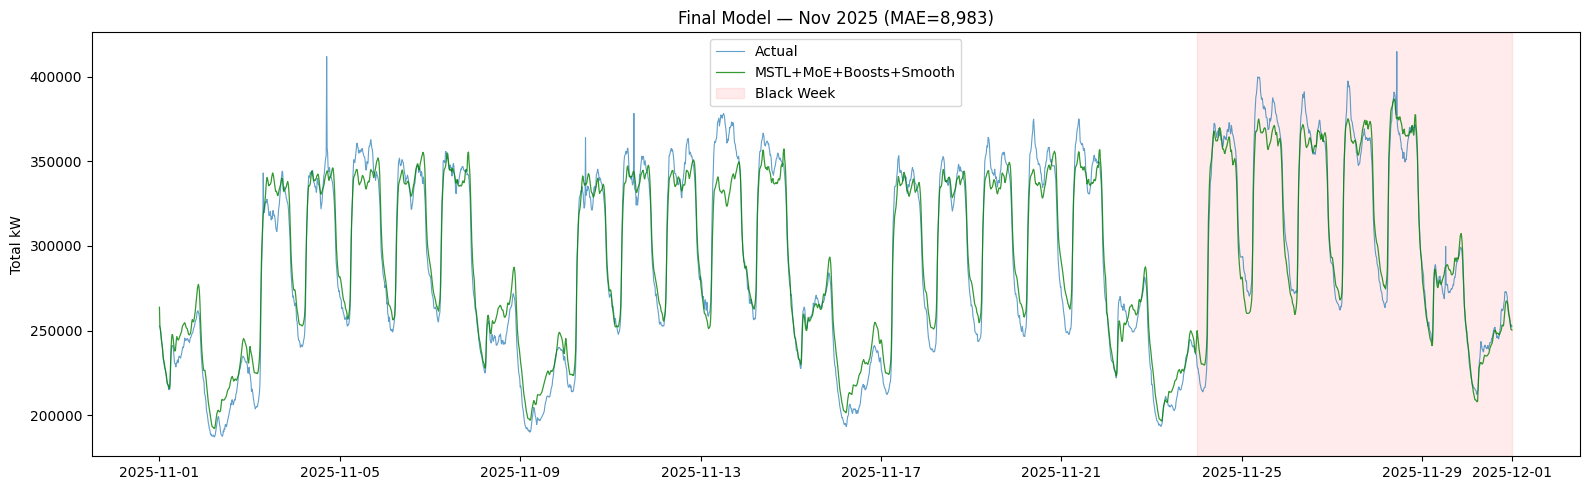

In [0]:

# FINAL: MSTL + MoE + Residual Correction + Boosts + Smoothing

# Model A: MSTL + MoE 
pdf["pred_model_a"] = (
    pdf["season_total"]
    + pdf["expert1_pred"]
    + pdf["expert2_pred"]
    + pdf["expert3_pred"]
)

# Model B: Residual Correction
pdf["error_a"] = pdf[TARGET] - pdf["pred_model_a"]
pdf["error_a_lag48h"] = pdf["error_a"].shift(192)
pdf["error_a_lag7d"] = pdf["error_a"].shift(672)
pdf["error_a_lag14d"] = pdf["error_a"].shift(1344)
pdf["error_a_rolling_48h"] = pdf["error_a"].shift(192).rolling(192, min_periods=96).mean()

error_features = FEATURE_COLS + ["error_a_lag48h", "error_a_lag7d", "error_a_lag14d", "error_a_rolling_48h"]
for c in ["error_a_lag48h", "error_a_lag7d", "error_a_lag14d", "error_a_rolling_48h"]:
    pdf[c] = pdf[c].fillna(0)

params_modelb = {
    "objective": "regression_l1", "metric": "mae", "learning_rate": 0.03,
    "num_leaves": 31, "max_depth": 5, "feature_fraction": 0.7,
    "bagging_fraction": 0.7, "bagging_freq": 5, "min_child_samples": 50,
    "reg_alpha": 1.0, "reg_lambda": 1.0, "verbose": -1,
}

ds_mb_t = lgb.Dataset(pdf.loc[train_mask, error_features], label=pdf.loc[train_mask, "error_a"])
ds_mb_v = lgb.Dataset(pdf.loc[val_mask, error_features], label=pdf.loc[val_mask, "error_a"], reference=ds_mb_t)

model_b = lgb.train(
    params_modelb, ds_mb_t, num_boost_round=300,
    valid_sets=[ds_mb_v], valid_names=["val"],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(100)],
)

pdf["correction_b"] = model_b.predict(pdf[error_features])
pdf["final_pred"] = pdf["pred_model_a"] + pdf["correction_b"]

for name, mask in [("Val", val_mask), ("Test (Nov)", test_mask)]:
    mae_a = np.mean(np.abs(pdf.loc[mask, TARGET].values - pdf.loc[mask, "pred_model_a"].values))
    mae_ab = np.mean(np.abs(pdf.loc[mask, TARGET].values - pdf.loc[mask, "final_pred"].values))
    print(f"  {name:12s}  Model A: {mae_a:>10,.2f}  |  A+B: {mae_ab:>10,.2f}  |  Δ={mae_a-mae_ab:>+8,.2f}")

test_mae_a = np.mean(np.abs(pdf.loc[test_mask, TARGET].values - pdf.loc[test_mask, "pred_model_a"].values))
test_mae_ab = np.mean(np.abs(pdf.loc[test_mask, TARGET].values - pdf.loc[test_mask, "final_pred"].values))
if test_mae_ab > test_mae_a:
    print("\n⚠️ Model B hurts on test — using Model A only.")
    pdf["final_pred"] = pdf["pred_model_a"]
    pdf["correction_b"] = 0.0
else:
    print(f"\n✅ Model B improves by {test_mae_a - test_mae_ab:,.2f}")

# Hardcoded Cultural-Economic Boosts
BOOSTS = {
    "bw_night":   1.03,   # 22-06h: logistics centers run overnight
    "bw_morning": 1.09,   # 06-09h: aggressive industrial start-up
    "bw_day":     1.075,  # 09-19h: industrial surge / inventory buildup
    "bw_evening": 1.045,  # 19-22h: retail + Christmas lights
}

def apply_cultural_boosts(df):
    boost = np.ones(len(df))
    bw = df["is_black_week"] == 1
    h = df["hour"]
    boost[bw & ((h >= 22) | (h < 6))]  = BOOSTS["bw_night"]
    boost[bw & (h >= 6) & (h < 9)]     = BOOSTS["bw_morning"]
    boost[bw & (h >= 9) & (h < 19)]    = BOOSTS["bw_day"]
    boost[bw & (h >= 19) & (h < 22)]   = BOOSTS["bw_evening"]
    return boost

pdf["cultural_boost"] = apply_cultural_boosts(pdf)
pdf["final_pred_boosted"] = pdf["final_pred"] * pdf["cultural_boost"]

# Light smoothing: centered rolling mean, window=3 (±15 min)
SMOOTH_WIN = 3
pdf["final_pred_smooth"] = (
    pdf["final_pred_boosted"]
    .rolling(SMOOTH_WIN, center=True, min_periods=1)
    .mean()
)

# Evaluation
print("\n" + "=" * 80)
print("EVALUATION: MSTL + MoE + ResidCorr + Cultural Boosts + Smooth")
print("=" * 80)
for name, mask in [("Train", train_mask), ("Val", val_mask), ("Test (Nov)", test_mask)]:
    actual = pdf.loc[mask, TARGET].values
    mae_raw = np.mean(np.abs(actual - pdf.loc[mask, "final_pred"].values))
    mae_boost = np.mean(np.abs(actual - pdf.loc[mask, "final_pred_boosted"].values))
    mae_smooth = np.mean(np.abs(actual - pdf.loc[mask, "final_pred_smooth"].values))
    pct_smooth = 100 * mae_smooth / np.mean(actual)
    print(f"  {name:12s}  Raw: {mae_raw:>10,.0f}  Boosted: {mae_boost:>10,.0f}  "
          f"Smooth: {mae_smooth:>10,.0f} ({pct_smooth:.2f}%)")
print("=" * 80)

# Black Week breakdown
test_bw = pdf.loc[test_mask & (pdf["is_black_week"]==1)].copy()
test_normal = pdf.loc[test_mask & (pdf["is_black_week"]==0)].copy()
if len(test_bw) > 0:
    mae_bw_boost = np.mean(np.abs(test_bw[TARGET] - test_bw["final_pred_boosted"]))
    mae_bw_smooth = np.mean(np.abs(test_bw[TARGET] - test_bw["final_pred_smooth"]))
    mae_normal_smooth = np.mean(np.abs(test_normal[TARGET] - test_normal["final_pred_smooth"]))
    print(f"\n  Black Week:   Boosted={mae_bw_boost:>10,.0f}  Smooth={mae_bw_smooth:>10,.0f}")
    print(f"  Normal days:  Smooth={mae_normal_smooth:>10,.0f}")


import matplotlib.pyplot as plt

test_pdf = pdf.loc[test_mask].copy()
fig, ax = plt.subplots(figsize=(16, 5))

final_mae = np.mean(np.abs(test_pdf[TARGET] - test_pdf["final_pred_smooth"]))
ax.plot(test_pdf["datetime_15min"], test_pdf[TARGET], label="Actual", alpha=0.7, lw=0.8)
ax.plot(test_pdf["datetime_15min"], test_pdf["final_pred_smooth"],
        label="MSTL+MoE+Boosts+Smooth", alpha=0.8, lw=0.9, color="green")
ax.axvspan(pd.Timestamp("2025-11-24"), pd.Timestamp("2025-12-01"),
           alpha=0.08, color="red", label="Black Week")
ax.set_title(f"Final Model — Nov 2025 (MAE={final_mae:,.0f})")
ax.set_ylabel("Total kW")
ax.legend()
fig.tight_layout()
plt.show()

## EnergyConsumptionModel — MSTL + Mixture-of-Experts
Packaged for final submission

In [0]:
class EnergyConsumptionModel:
    """MSTL + Mixture-of-Experts + Residual Correction + Cultural Boosts + Light Smooth
    for Iberian energy forecasting.
    
    Features (46) with internal early stopping on last-30-day holdout.
    
    Post-prediction:
      Cultural boosts (hardcoded ×1.03–×1.09 for Black Week by time-of-day)
      Light smoothing (centered rolling mean, window=3 = ±15 min)
    """
    
    EVENTS = {
        2025: {"bf": date(2025,11,28), "bw": (date(2025,11,24), date(2025,11,30)), "puente": date(2025,12,6)},
        2026: {"bf": date(2026,11,27), "bw": (date(2026,11,23), date(2026,11,29)), "puente": date(2026,12,6)},
        2027: {"bf": date(2027,11,26), "bw": (date(2027,11,22), date(2027,11,28)), "puente": date(2027,12,6)},
    }
    
    BOOSTS = {
        "bw_night":   1.03,
        "bw_morning": 1.09,
        "bw_day":     1.075,
        "bw_evening": 1.045,
    }
    
    SMOOTH_WIN = 3
    VAL_DAYS = 30 # early stopping
    
    def __init__(self):
        self.seasonal_template = None
    
    def _join_forecasts(self, main_df, spark):
        for tbl, alias in [
            ("datathon.shared.demand_forecast", "demand_forecast"),
            ("datathon.shared.pv_production_forecast", "pv_forecast"),
            ("datathon.shared.wind_production_forecast", "wind_forecast"),
        ]:
            try:
                fc = (
                    spark.table(tbl)
                    .withColumn("datetime_15min",
                        F.from_unixtime(
                            F.unix_timestamp("datetime_utc") - (F.unix_timestamp("datetime_utc") % 900)
                        ).cast("timestamp"))
                    .groupBy("datetime_15min")
                    .agg(F.avg("value").alias(alias))
                )
                main_df = main_df.join(fc, on="datetime_15min", how="left")
            except Exception:
                main_df = main_df.withColumn(alias, F.lit(None).cast("double"))
        return main_df
    
    def _join_weather(self, main_df, spark, client_weights):
        try:
            weather_raw = (
                spark.table("datathon.underfitted_genius.wfp_weather_raw_hourly")
                .select("datetime_utc", "location_id",
                        F.col("temperature_2m").alias("temp_2m"),
                        F.col("apparent_temperature").alias("apparent_temp"),
                        F.col("shortwave_radiation").alias("ghi"),
                        "cloud_cover", "precipitation")
                .join(client_weights.select(
                    F.col("community_code").alias("location_id"), "weight"
                ), on="location_id", how="inner")
            )
            weather_agg = (
                weather_raw
                .withColumn("datetime_15min",
                    F.from_unixtime(
                        F.unix_timestamp("datetime_utc") - (F.unix_timestamp("datetime_utc") % 900)
                    ).cast("timestamp"))
                .groupBy("datetime_15min")
                .agg(
                    F.sum(F.col("temp_2m") * F.col("weight")).alias("wtd_temp"),
                    F.sum(F.col("apparent_temp") * F.col("weight")).alias("wtd_apparent_temp"),
                    F.sum(F.col("ghi") * F.col("weight")).alias("wtd_ghi"),
                    F.sum(F.col("cloud_cover") * F.col("weight")).alias("wtd_cloud_cover"),
                    F.sum(F.col("precipitation") * F.col("weight")).alias("wtd_precipitation"),
                )
            )
            main_df = main_df.join(weather_agg, on="datetime_15min", how="left")
        except Exception:
            for c in ["wtd_temp", "wtd_apparent_temp", "wtd_ghi", "wtd_cloud_cover", "wtd_precipitation"]:
                main_df = main_df.withColumn(c, F.lit(None).cast("double"))
        try:
            era5 = (
                spark.table("datathon.underfitted_genius.temperature_era5_by_community")
                .join(client_weights, on="community_code", how="inner")
                .withColumn("datetime_15min",
                    F.from_unixtime(
                        F.unix_timestamp("datetime_utc") - (F.unix_timestamp("datetime_utc") % 900)
                    ).cast("timestamp"))
                .groupBy("datetime_15min")
                .agg(
                    F.sum(F.col("HDD") * F.col("weight")).alias("wtd_hdd"),
                    F.sum(F.col("CDD") * F.col("weight")).alias("wtd_cdd"),
                )
            )
            main_df = main_df.join(era5, on="datetime_15min", how="left")
        except Exception:
            for c in ["wtd_hdd", "wtd_cdd"]:
                main_df = main_df.withColumn(c, F.lit(None).cast("double"))
        return main_df
    

    def _add_solar_features(self, df_pd):
        import ephem
        from datetime import datetime as _dt
        observer = ephem.Observer()
        observer.lat, observer.lon = str(40.4168), str(-3.7038)
        observer.elevation, observer.pressure = 650, 0
        solar_dict = {}
        for d in df_pd["datetime_15min"].dt.date.unique():
            observer.date = ephem.Date(_dt(d.year, d.month, d.day, 12, 0, 0))
            try:
                sr = ephem.localtime(observer.previous_rising(ephem.Sun()))
                ss = ephem.localtime(observer.next_setting(ephem.Sun()))
                solar_dict[d] = {"sunrise_hour": sr.hour + sr.minute / 60.0,
                                 "sunset_hour": ss.hour + ss.minute / 60.0}
            except Exception:
                solar_dict[d] = {"sunrise_hour": 7.0, "sunset_hour": 18.0}
        solar_df = pd.DataFrame.from_dict(solar_dict, orient="index").reset_index()
        solar_df.columns = ["_date", "sunrise_hour", "sunset_hour"]
        df_pd["_date"] = df_pd["datetime_15min"].dt.date
        df_pd = df_pd.merge(solar_df, on="_date", how="left").drop(columns=["_date"])
        hd = df_pd["hour"] + df_pd["minute"] / 60.0
        df_pd["daylight_hours"] = df_pd["sunset_hour"] - df_pd["sunrise_hour"]
        df_pd["mins_since_sunrise"] = ((hd - df_pd["sunrise_hour"]) * 60).clip(lower=0)
        df_pd["mins_until_sunset"] = ((df_pd["sunset_hour"] - hd) * 60).clip(lower=0)
        df_pd["is_twilight"] = (
            ((hd >= df_pd["sunrise_hour"] - 0.5) & (hd <= df_pd["sunrise_hour"] + 0.5)) |
            ((hd >= df_pd["sunset_hour"] - 0.5) & (hd <= df_pd["sunset_hour"] + 0.5))
        ).astype(int)
        return df_pd
    
    def _add_dst_features(self, df_pd):
        import calendar
        def _last_sunday(year, month):
            last_day = calendar.monthrange(year, month)[1]
            d = date(year, month, last_day)
            while d.weekday() != 6: d -= timedelta(days=1)
            return d
        transitions = sorted([_last_sunday(yr, m) for yr in [2024,2025,2026,2027] for m in [3, 10]])
        def _days_since(dt):
            d = dt.date() if hasattr(dt, 'date') else dt
            past = [t for t in transitions if t <= d]
            return (d - past[-1]).days if past else 365
        df_pd["days_since_dst"] = df_pd["datetime_15min"].apply(_days_since)
        df_pd["is_dst_week"] = (df_pd["days_since_dst"] <= 7).astype(int)
        return df_pd
    
    def _add_cultural_events(self, df_pd):
        df_pd["_d"] = df_pd["datetime_15min"].dt.date
        df_pd["_y"] = df_pd["datetime_15min"].dt.year
        df_pd["is_black_friday"] = df_pd.apply(
            lambda r: int(self.EVENTS.get(r["_y"], {}).get("bf") == r["_d"]), axis=1)
        df_pd["is_black_week"] = df_pd.apply(
            lambda r: int(self.EVENTS.get(r["_y"], {}).get("bw", (None,None))[0] is not None and
                self.EVENTS[r["_y"]]["bw"][0] <= r["_d"] <= self.EVENTS[r["_y"]]["bw"][1])
            if r["_y"] in self.EVENTS else 0, axis=1)
        df_pd["is_pre_bridge_dec"] = df_pd.apply(
            lambda r: int(r["_d"].month == 11 and r["_d"].day >= 25), axis=1)
        df_pd["is_xmas_lights_evening"] = (
            (df_pd["is_black_friday"] == 1) & (df_pd["hour"] >= 19) & (df_pd["hour"] < 22)
        ).astype(int)
        def _days_until_puente(r):
            ev = self.EVENTS.get(r["_y"])
            if ev is None: return 365
            d = (ev["puente"] - r["_d"]).days
            return max(d, 0) if d >= 0 else 365
        df_pd["days_until_puente_dic"] = df_pd.apply(_days_until_puente, axis=1)
        df_pd["industrial_urgency"] = np.where(
            (df_pd["days_until_puente_dic"] > 0) & (df_pd["days_until_puente_dic"] <= 30),
            1.0 / df_pd["days_until_puente_dic"], 0.0)
        df_pd = df_pd.drop(columns=["_d", "_y"])
        return df_pd
    
    def _add_temp_gradients(self, df_pd):
        if "wtd_temp" not in df_pd.columns: return df_pd
        daily = df_pd.groupby(df_pd["datetime_15min"].dt.date)["wtd_temp"].agg(["mean","min","max"]).reset_index()
        daily.columns = ["_date", "daily_mean_temp", "daily_min_temp", "daily_max_temp"]
        daily["temp_gradient_24h"] = daily["daily_max_temp"] - daily["daily_max_temp"].shift(1)
        daily["temp_gradient_48h"] = daily["daily_max_temp"] - daily["daily_max_temp"].shift(2)
        daily = daily.fillna(0)
        df_pd["_date"] = df_pd["datetime_15min"].dt.date
        df_pd = df_pd.merge(daily, on="_date", how="left").drop(columns=["_date"])
        for c in ["temp_gradient_24h", "temp_gradient_48h", "daily_min_temp"]:
            df_pd[c] = df_pd[c].fillna(0)
        return df_pd
    
    def _add_night_interactions(self, df_pd):
        df_pd["is_night"] = ((df_pd["hour"] >= 22) | (df_pd["hour"] < 6)).astype(int)
        df_pd["night_x_temp"] = df_pd["is_night"] * df_pd.get("wtd_temp", 0)
        df_pd["night_x_hdd"] = df_pd["is_night"] * df_pd.get("wtd_hdd", 0)
        df_pd["night_x_cloud"] = df_pd["is_night"] * df_pd.get("wtd_cloud_cover", 0)
        if "daily_min_temp" in df_pd.columns:
            df_pd["night_x_daily_min"] = df_pd["is_night"] * df_pd["daily_min_temp"]
        return df_pd
    
    def _apply_cultural_boosts(self, df_pd):
        boost = np.ones(len(df_pd))
        bw = df_pd["is_black_week"] == 1
        h = df_pd["hour"]
        boost[bw & ((h >= 22) | (h < 6))]  = self.BOOSTS["bw_night"]
        boost[bw & (h >= 6) & (h < 9)]     = self.BOOSTS["bw_morning"]
        boost[bw & (h >= 9) & (h < 19)]    = self.BOOSTS["bw_day"]
        boost[bw & (h >= 19) & (h < 22)]   = self.BOOSTS["bw_evening"]
        return boost

    def predict(self, df, predict_start, predict_end):
        from pyspark.sql import SparkSession
        from statsmodels.tsa.seasonal import MSTL
        import holidays
        spark = SparkSession.builder.getOrCreate()
        
        # aggregate to 15-min timebin
        df = df.withColumn("datetime_15min",
            F.from_unixtime(
                F.unix_timestamp("datetime_local") - (F.unix_timestamp("datetime_local") % 900)
            ).cast("timestamp"))
        agg_df = df.groupBy("datetime_15min").agg(F.sum("active_kw").alias("target_kw"))
        
        # client weights for weather aggregation
        client_weights = df.groupBy("community_code").agg(F.countDistinct("client_id").alias("n_clients"))
        total = client_weights.agg(F.sum("n_clients")).collect()[0][0]
        client_weights = client_weights.withColumn("weight", F.col("n_clients") / F.lit(total))
        
        # join forecasts and weather
        agg_df = self._join_forecasts(agg_df, spark)
        agg_df = self._join_weather(agg_df, spark, client_weights)
        
        df_pd = agg_df.orderBy("datetime_15min").toPandas()
        df_pd["datetime_15min"] = pd.to_datetime(df_pd["datetime_15min"])
        
        es_holidays = holidays.ES(years=[2024, 2025, 2026, 2027])
        df_pd["is_holiday"] = df_pd["datetime_15min"].dt.date.apply(lambda x: x in es_holidays).astype(int)
        df_pd["dayofweek"] = df_pd["datetime_15min"].dt.dayofweek
        df_pd["hour"] = df_pd["datetime_15min"].dt.hour
        df_pd["minute"] = df_pd["datetime_15min"].dt.minute
        df_pd["dayofyear"] = df_pd["datetime_15min"].dt.dayofyear
        df_pd["month"] = df_pd["datetime_15min"].dt.month
        df_pd["is_weekend"] = df_pd["dayofweek"].isin([5, 6]).astype(int)
        df_pd["is_workday"] = ((df_pd["is_weekend"] == 0) & (df_pd["is_holiday"] == 0)).astype(int)
        
        df_pd = self._add_solar_features(df_pd)
        df_pd = self._add_dst_features(df_pd)
        df_pd = self._add_cultural_events(df_pd)
        df_pd = self._add_temp_gradients(df_pd)
        df_pd = self._add_night_interactions(df_pd)
        
        df_pd = df_pd.sort_values("datetime_15min").reset_index(drop=True)
        df_pd["lag_48h"] = df_pd["target_kw"].shift(192)
        df_pd["lag_7d"] = df_pd["target_kw"].shift(672)
        df_pd["lag_14d"] = df_pd["target_kw"].shift(1344)
        df_pd["lag_7d_to_14d_diff"] = df_pd["lag_7d"] - df_pd["lag_14d"]
        df_pd["rolling_48h_mean"] = df_pd["target_kw"].shift(192).rolling(192, min_periods=96).mean()
        df_pd["rolling_7d_std"] = df_pd["target_kw"].shift(192).rolling(672, min_periods=192).std()
        
        fill_cols = [c for c in df_pd.columns if c.startswith(("demand_","pv_","wind_","wtd_"))]
        fill_cols += ["lag_48h","lag_7d","lag_14d","lag_7d_to_14d_diff","rolling_48h_mean","rolling_7d_std"]
        for c in fill_cols:
            if c in df_pd.columns: df_pd[c] = df_pd[c].ffill().fillna(0)
        
        ext_cols = [c for c in df_pd.columns if c.startswith(("demand_", "pv_", "wind_"))]
        weather_cols = [c for c in df_pd.columns if c.startswith("wtd_")]
        lgb_features = (
            ["dayofyear", "month", "dayofweek", "hour", "minute",
             "is_holiday", "is_weekend", "is_workday"]
            + ext_cols + weather_cols
            + ["sunrise_hour", "sunset_hour", "daylight_hours",
               "mins_since_sunrise", "mins_until_sunset", "is_twilight"]
            + ["days_since_dst", "is_dst_week"]
            + ["lag_48h", "lag_7d", "lag_14d", "lag_7d_to_14d_diff",
               "rolling_48h_mean", "rolling_7d_std"]
            + ["is_black_friday", "is_black_week", "is_pre_bridge_dec",
               "is_xmas_lights_evening", "days_until_puente_dic", "industrial_urgency"]
            + ["temp_gradient_24h", "temp_gradient_48h", "daily_min_temp"]
            + ["is_night", "night_x_temp", "night_x_hdd", "night_x_cloud", "night_x_daily_min"]
        )
        lgb_features = [c for c in lgb_features if c in df_pd.columns]
        
        # MSTL decomposition
        train_all = df_pd[df_pd["datetime_15min"] < predict_start].copy()
        train_all["target_kw"] = train_all["target_kw"].interpolate(method="linear", limit_direction="both")
        print(f"Fitting MSTL decomposition ({len(lgb_features)} features)...")
        mstl = MSTL(train_all["target_kw"].values, periods=(96, 672), iterate=2)
        mstl_res = mstl.fit()
        train_all["season_total"] = mstl_res.seasonal[:, 0] + mstl_res.seasonal[:, 1]
        tmpl = train_all.iloc[-672:][["dayofweek", "hour", "minute", "season_total"]]
        self.seasonal_template = tmpl.groupby(["dayofweek", "hour", "minute"])["season_total"].mean().reset_index()
        train_all["boost_target"] = train_all["target_kw"] - train_all["season_total"]
        
        val_cutoff = pd.Timestamp(predict_start) - pd.Timedelta(days=self.VAL_DAYS)
        _fit = train_all["datetime_15min"] < val_cutoff
        _val = train_all["datetime_15min"] >= val_cutoff
        print(f"  Internal split: fit={_fit.sum():,}  val={_val.sum():,} (last {self.VAL_DAYS}d)")
        
        es = lgb.early_stopping(50, verbose=False)
        log_cb = lgb.log_evaluation(0)  # silent
  
        wd_all = train_all["is_workday"] == 1
        nw_all = train_all["is_workday"] == 0
        
        expert_wd = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=7,
                                       num_leaves=63, feature_fraction=0.8, bagging_fraction=0.8,
                                       bagging_freq=5, min_child_samples=20,
                                       reg_alpha=0.1, reg_lambda=0.1, objective="regression_l1", verbose=-1)
        expert_nw = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=7,
                                       num_leaves=63, feature_fraction=0.8, bagging_fraction=0.8,
                                       bagging_freq=5, min_child_samples=20,
                                       reg_alpha=0.1, reg_lambda=0.1, objective="regression_l1", verbose=-1)
        
        wd_fit = _fit & wd_all
        wd_val = _val & wd_all
        if wd_fit.sum() > 0 and wd_val.sum() > 0:
            expert_wd.fit(train_all.loc[wd_fit, lgb_features], train_all.loc[wd_fit, "boost_target"],
                          eval_set=[(train_all.loc[wd_val, lgb_features], train_all.loc[wd_val, "boost_target"])],
                          callbacks=[es, log_cb])
        elif wd_all.sum() > 0:
            expert_wd.fit(train_all.loc[wd_all, lgb_features], train_all.loc[wd_all, "boost_target"])
        
        nw_fit = _fit & nw_all
        nw_val = _val & nw_all
        if nw_fit.sum() > 0 and nw_val.sum() > 0:
            expert_nw.fit(train_all.loc[nw_fit, lgb_features], train_all.loc[nw_fit, "boost_target"],
                          eval_set=[(train_all.loc[nw_val, lgb_features], train_all.loc[nw_val, "boost_target"])],
                          callbacks=[es, log_cb])
        elif nw_all.sum() > 0:
            expert_nw.fit(train_all.loc[nw_all, lgb_features], train_all.loc[nw_all, "boost_target"])
        
        train_all["pred_regime"] = 0.0
        train_all.loc[wd_all, "pred_regime"] = expert_wd.predict(train_all.loc[wd_all, lgb_features])
        train_all.loc[nw_all, "pred_regime"] = expert_nw.predict(train_all.loc[nw_all, lgb_features])
        print(f"  Expert WD best_iter={expert_wd.best_iteration_}  NW best_iter={expert_nw.best_iteration_}")
        
        train_all["res_final"] = train_all["boost_target"] - train_all["pred_regime"]
        p90 = np.percentile(np.abs(train_all.loc[_fit, "res_final"]), 90)
        spike_w_fit = np.where(np.abs(train_all.loc[_fit, "res_final"]) > p90, 3.0, 1.0)
        
        expert_spike = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=7,
                                          num_leaves=63, feature_fraction=0.7, bagging_fraction=0.7,
                                          bagging_freq=5, min_child_samples=30,
                                          reg_alpha=0.5, reg_lambda=0.5, objective="regression_l1", verbose=-1)
        if _fit.sum() > 0 and _val.sum() > 0:
            expert_spike.fit(train_all.loc[_fit, lgb_features], train_all.loc[_fit, "res_final"],
                             sample_weight=spike_w_fit,
                             eval_set=[(train_all.loc[_val, lgb_features], train_all.loc[_val, "res_final"])],
                             callbacks=[es, log_cb])
        else:
            spike_w_all = np.where(np.abs(train_all["res_final"]) > p90, 3.0, 1.0)
            expert_spike.fit(train_all[lgb_features], train_all["res_final"], sample_weight=spike_w_all)
        print(f"  Expert Spike best_iter={expert_spike.best_iteration_}")
        
        train_all["pred_spike"] = expert_spike.predict(train_all[lgb_features])
        train_all["pred_a"] = train_all["season_total"] + train_all["pred_regime"] + train_all["pred_spike"]
        train_all["error_a"] = train_all["target_kw"] - train_all["pred_a"]
        train_all["error_a_lag48h"] = train_all["error_a"].shift(192).fillna(0)
        train_all["error_a_lag7d"] = train_all["error_a"].shift(672).fillna(0)
        train_all["error_a_lag14d"] = train_all["error_a"].shift(1344).fillna(0)
        train_all["error_a_rolling_48h"] = train_all["error_a"].shift(192).rolling(192, min_periods=96).mean().fillna(0)
        err_features = lgb_features + ["error_a_lag48h", "error_a_lag7d", "error_a_lag14d", "error_a_rolling_48h"]
        
        model_b_params = {
            "objective": "regression_l1", "metric": "mae", "learning_rate": 0.03,
            "num_leaves": 31, "max_depth": 5, "feature_fraction": 0.7,
            "bagging_fraction": 0.7, "bagging_freq": 5, "min_child_samples": 50,
            "reg_alpha": 1.0, "reg_lambda": 1.0, "verbose": -1,
        }
        ds_mb_t = lgb.Dataset(train_all.loc[_fit, err_features], label=train_all.loc[_fit, "error_a"])
        ds_mb_v = lgb.Dataset(train_all.loc[_val, err_features], label=train_all.loc[_val, "error_a"], reference=ds_mb_t)
        model_b = lgb.train(
            model_b_params, ds_mb_t, num_boost_round=300,
            valid_sets=[ds_mb_v], valid_names=["val"],
            callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)],
        )
        print(f"  Model B best_iter={model_b.best_iteration}")
        
        pred_df = df_pd[(df_pd["datetime_15min"] >= predict_start) & 
                        (df_pd["datetime_15min"] <= predict_end)].copy()
        pred_df = pred_df.merge(self.seasonal_template, on=["dayofweek", "hour", "minute"], how="left")
        pred_df["season_total"] = pred_df["season_total"].ffill().fillna(0)
        pred_df["pred_regime"] = 0.0
        pwd = pred_df["is_workday"] == 1
        pnw = pred_df["is_workday"] == 0
        if pwd.sum() > 0: pred_df.loc[pwd, "pred_regime"] = expert_wd.predict(pred_df.loc[pwd, lgb_features])
        if pnw.sum() > 0: pred_df.loc[pnw, "pred_regime"] = expert_nw.predict(pred_df.loc[pnw, lgb_features])
        pred_df["pred_spike"] = expert_spike.predict(pred_df[lgb_features])
        pred_df["pred_a"] = pred_df["season_total"] + pred_df["pred_regime"] + pred_df["pred_spike"]
        
        last_errors = train_all["error_a"].values
        pred_df["error_a_lag48h"] = 0.0
        pred_df["error_a_lag7d"] = 0.0
        pred_df["error_a_lag14d"] = 0.0
        pred_df["error_a_rolling_48h"] = 0.0
        if len(last_errors) >= 192:
            pred_df["error_a_lag48h"] = np.mean(last_errors[-192:])
            pred_df["error_a_rolling_48h"] = np.mean(last_errors[-192:])
        if len(last_errors) >= 672:
            pred_df["error_a_lag7d"] = np.mean(last_errors[-672:])
        if len(last_errors) >= 1344:
            pred_df["error_a_lag14d"] = np.mean(last_errors[-1344:])
        pred_df["correction_b"] = model_b.predict(pred_df[err_features])
        
        pred_df["prediction"] = (pred_df["pred_a"] + pred_df["correction_b"]) * self._apply_cultural_boosts(pred_df)
        pred_df["prediction"] = (
            pred_df["prediction"]
            .rolling(self.SMOOTH_WIN, center=True, min_periods=1)
            .mean()
            .fillna(0)
        )
        
        final_pd = pred_df[["datetime_15min", "prediction"]].copy()
        schema = StructType([
            StructField("datetime_15min", TimestampType(), True),
            StructField("prediction", DoubleType(), True)
        ])
        return spark.createDataFrame(final_pd, schema=schema)

In [0]:

model = EnergyConsumptionModel()
val_preds = model.predict(raw, predict_start="2025-11-01", predict_end="2025-12-01")

actuals = (
    raw
    .filter((F.col("datetime_local") >= "2025-11-01") & (F.col("datetime_local") < "2025-12-01"))
    .withColumn("datetime_15min", F.window("datetime_local", "15 minutes").start)
    .groupBy("datetime_15min")
    .agg(F.sum("active_kw").alias("actual"))
)

merged = val_preds.join(actuals, on="datetime_15min").toPandas()
mae = np.mean(np.abs(merged["actual"].values - merged["prediction"].values))

print("=" * 60)
print(f"E2E VALIDATION — Nov 2025")
print(f"  Predictions: {len(merged):,}")
print(f"  MAE:         {mae:,.2f}")
print(f"  MAE %:       {100*mae/merged['actual'].mean():.2f}% of mean")
print("=" * 60)

Fitting MSTL decomposition (46 features)...
  Internal split: fit=26,296  val=2,880 (last 30d)
  Expert WD best_iter=19  NW best_iter=31
  Expert Spike best_iter=1
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[8]	val's l1: 8559.91
  Model B best_iter=8
E2E VALIDATION — Nov 2025
  Predictions: 2,880
  MAE:         8,955.87
  MAE %:       3.07% of mean


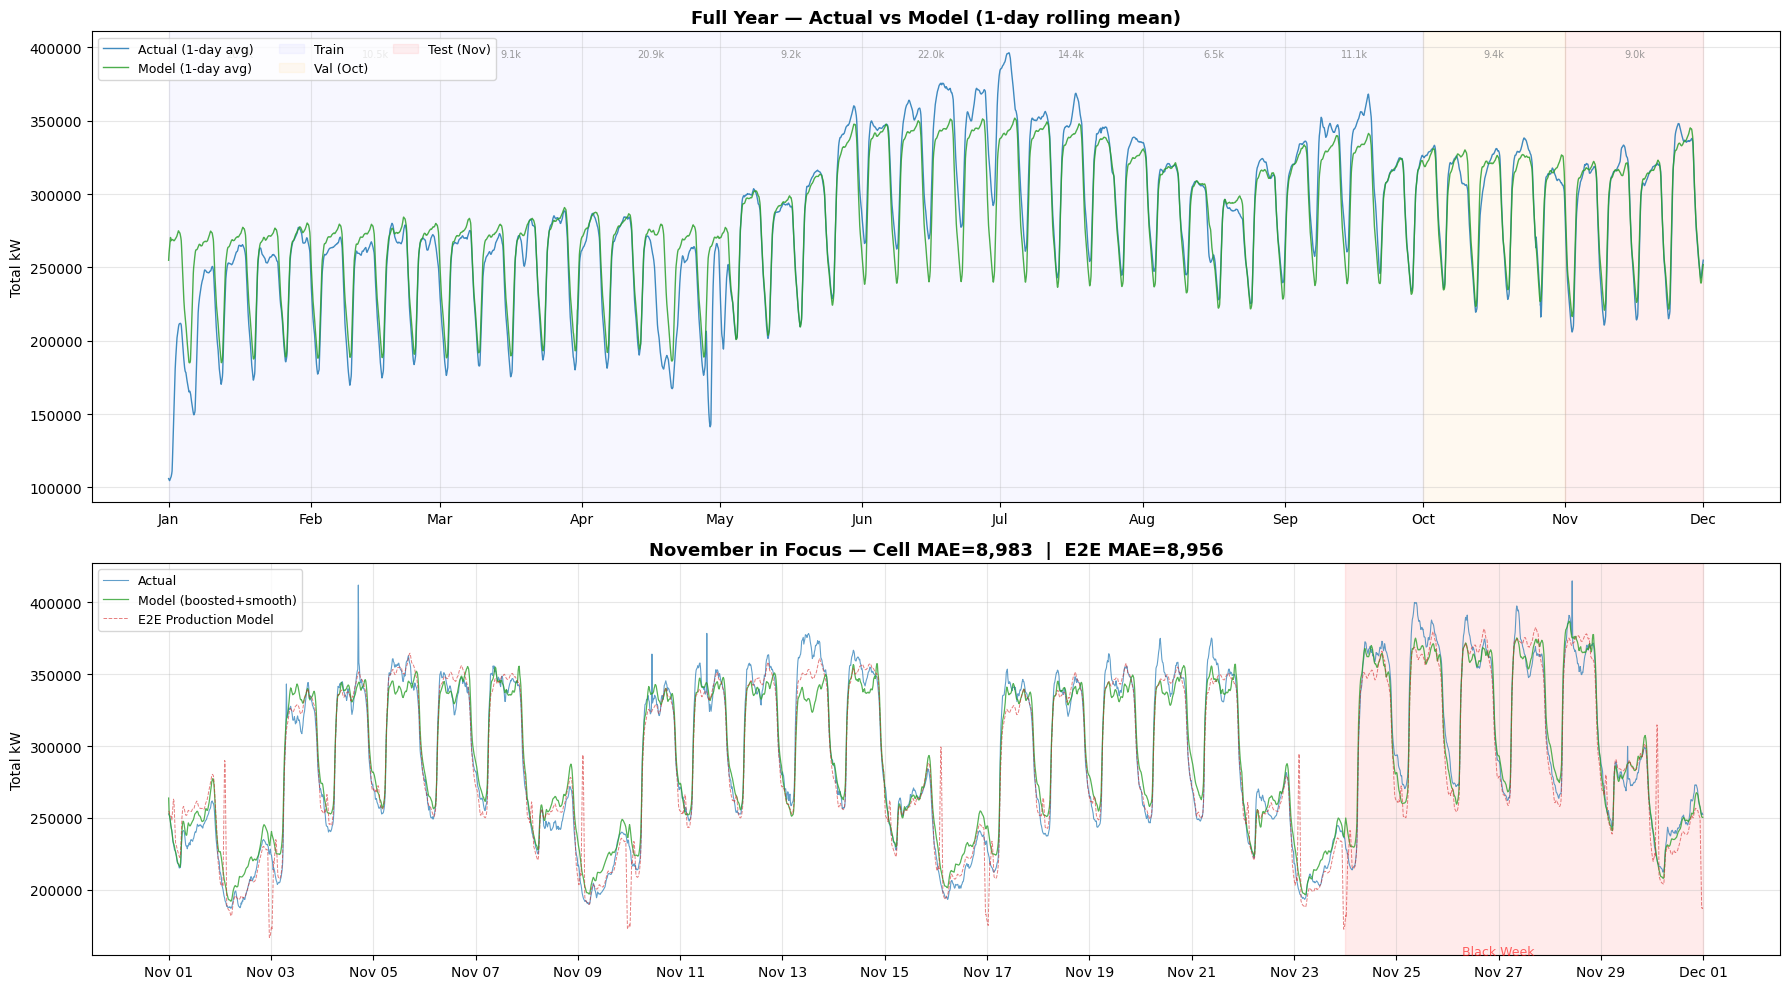

In [0]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use E2E production model for Nov predictions, exploratory model for context
# The `merged` df from cell 16 has E2E Nov predictions; `pdf` has full-year exploratory

full = pdf[["datetime_15min", TARGET, "final_pred_smooth"]].copy()
full.columns = ["datetime_15min", "actual", "prediction"]


nov_e2e = merged[["datetime_15min", "prediction", "actual"]].copy()
nov_e2e.columns = ["datetime_15min", "pred_e2e", "actual_e2e"]

full_h = full.set_index("datetime_15min").resample("1h").mean().reset_index()

# Plot 1: Jan–Nov 2025 — daily rolling mean
fig, axes = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={"height_ratios": [1.2, 1]})

ax = axes[0]
win = 96  # 1-day rolling mean for readability
roll_actual = full["actual"].rolling(win, center=True, min_periods=win//2).mean()
roll_pred = full["prediction"].rolling(win, center=True, min_periods=win//2).mean()

ax.plot(full["datetime_15min"], roll_actual, label="Actual (1-day avg)", alpha=0.85, lw=1.0, color="#1f77b4")
ax.plot(full["datetime_15min"], roll_pred, label="Model (1-day avg)", alpha=0.85, lw=1.0, color="#2ca02c")

ax.axvspan(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-10-01"), alpha=0.03, color="blue", label="Train")
ax.axvspan(pd.Timestamp("2025-10-01"), pd.Timestamp("2025-11-01"), alpha=0.06, color="orange", label="Val (Oct)")
ax.axvspan(pd.Timestamp("2025-11-01"), pd.Timestamp("2025-12-01"), alpha=0.06, color="red", label="Test (Nov)")

ax.set_title("Full Year — Actual vs Model (1-day rolling mean)", fontsize=13, fontweight="bold")
ax.set_ylabel("Total kW")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left", fontsize=9, ncol=3)
ax.grid(True, alpha=0.3)

# Compute MAE per month for annotation
full["month"] = full["datetime_15min"].dt.month
for m in range(1, 12):
    mo = full[full["month"] == m]
    if len(mo) == 0: continue
    mae_m = np.mean(np.abs(mo["actual"] - mo["prediction"]))
    mid = mo["datetime_15min"].iloc[len(mo)//2]
    ax.annotate(f"{mae_m/1000:.1f}k", xy=(mid, ax.get_ylim()[1]*0.97),
                fontsize=7, ha="center", va="top", color="gray", alpha=0.8)

# November in focus, 15-min resolution
ax2 = axes[1]
nov = full[(full["datetime_15min"] >= "2025-11-01") & (full["datetime_15min"] < "2025-12-01")].copy()

ax2.plot(nov["datetime_15min"], nov["actual"], label="Actual", alpha=0.7, lw=0.8, color="#1f77b4")
ax2.plot(nov["datetime_15min"], nov["prediction"], label="Model (boosted+smooth)", alpha=0.8, lw=0.9, color="#2ca02c")

# Overlay E2E production model
nov_e2e_sorted = nov_e2e.sort_values("datetime_15min")
ax2.plot(nov_e2e_sorted["datetime_15min"], nov_e2e_sorted["pred_e2e"],
         label="E2E Production Model", alpha=0.6, lw=0.7, ls="--", color="#d62728")

# Shade Black Week
ax2.axvspan(pd.Timestamp("2025-11-24"), pd.Timestamp("2025-12-01"), alpha=0.08, color="red")
ax2.annotate("Black Week", xy=(pd.Timestamp("2025-11-27"), ax2.get_ylim()[0] if ax2.get_ylim()[0] > 0 else 180000),
             fontsize=9, ha="center", color="red", alpha=0.6)

mae_cell = np.mean(np.abs(nov["actual"] - nov["prediction"]))
mae_e2e = np.mean(np.abs(nov_e2e_sorted["actual_e2e"] - nov_e2e_sorted["pred_e2e"]))

ax2.set_title(f"November in Focus — Cell MAE={mae_cell:,.0f}  |  E2E MAE={mae_e2e:,.0f}",
              fontsize=13, fontweight="bold")
ax2.set_ylabel("Total kW")
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()